# <font color = blue> 1. Loading Data </font>

In [1]:
# Importing modules
import pandas as pd
import os
os.getcwd()

'C:\\Users\\jieum\\DataAnalysis\\NIPSPapers'

In [29]:
# Read data into papers
papers = pd.read_csv('papers.csv')

In [30]:
# Print head
papers.head()

,id,year,title,event_type,pdf_name,abstract,paper_text
0,1,1987,Self-Organization of Associative Database and ...,NaN,1-self-organization-of-associative-database-an...,Abstract Missing,767\n\nSELF-ORGANIZATION OF ASSOCIATIVE DATABA...
1,10,1987,A Mean Field Theory of Layer IV of Visual Cort...,NaN,10-a-mean-field-theory-of-layer-iv-of-visual-c...,Abstract Missing,683\n\nA MEAN FIELD THEORY OF LAYER IV OF VISU...
2,100,1988,Storing Covariance by the Associative Long-Ter...,NaN,100-storing-covariance-by-the-associative-long...,Abstract Missing,394\n\nSTORING COVARIANCE BY THE ASSOCIATIVE\n...
3,1000,1994,Bayesian Query Construction for Neural Network...,NaN,1000-bayesian-query-construction-for-neural-ne...,Abstract Missing,Bayesian Query Construction for Neural\nNetwor...
4,1001,1994,"Neural Network Ensembles, Cross Validation, an...",NaN,1001-neural-network-ensembles-cross-validation...,Abstract Missing,"Neural Network Ensembles, Cross\nValidation, a..."


In [31]:
len(papers)

6560

# <font color = blue> 2. Data Cleaning </font>
- focus only on the text data 
- drop other metadata
- only look at 100 papers

In [32]:
# Remove metadata 
# axis=1; drop columns, axis=0; drop rows
# sample 100 randomly 
papers = \
papers.drop(columns=['id', 'event_type', 'pdf_name'], axis=1).sample(100, random_state=2024)
papers.head()

,year,title,abstract,paper_text
5413,1992,Computing with Almost Optimal Size Neural Netw...,Abstract Missing,Computing with Almost Optimal Size Neural\nNet...
1519,2003,A Sampled Texture Prior for Image Super-Resolu...,Abstract Missing,A Sampled Texture Prior for Image\nSuper-Resol...
4532,2013,Moment-based Uniform Deviation Bounds for,Suppose $k$ centers are fit to $m$ points by h...,Moment-based Uniform Deviation Bounds for\nk-m...
2883,2008,Improving on Expectation Propagation,We develop as series of corrections to Expecta...,Improving on Expectation Propagation\n\nManfre...
3743,1990,The Devil and the Network: What Sparsity Impli...,Abstract Missing,The Devil and the Network:\nWhat Sparsity Impl...


## <font color = green> Remove punctuation/ Lower case </font>

In [33]:
# remove punctuations
# regular expression
import re

papers['paper_text_processed'] = \
papers['paper_text'].apply(lambda x:re.sub('[,\.?!]', '', x))
papers.head()

,year,title,abstract,paper_text,paper_text_processed
5413,1992,Computing with Almost Optimal Size Neural Netw...,Abstract Missing,Computing with Almost Optimal Size Neural\nNet...,Computing with Almost Optimal Size Neural\nNet...
1519,2003,A Sampled Texture Prior for Image Super-Resolu...,Abstract Missing,A Sampled Texture Prior for Image\nSuper-Resol...,A Sampled Texture Prior for Image\nSuper-Resol...
4532,2013,Moment-based Uniform Deviation Bounds for,Suppose $k$ centers are fit to $m$ points by h...,Moment-based Uniform Deviation Bounds for\nk-m...,Moment-based Uniform Deviation Bounds for\nk-m...
2883,2008,Improving on Expectation Propagation,We develop as series of corrections to Expecta...,Improving on Expectation Propagation\n\nManfre...,Improving on Expectation Propagation\n\nManfre...
3743,1990,The Devil and the Network: What Sparsity Impli...,Abstract Missing,The Devil and the Network:\nWhat Sparsity Impl...,The Devil and the Network:\nWhat Sparsity Impl...


In [34]:
# lowercase paper_text
papers['paper_text_processed'] = \
papers['paper_text_processed'].apply(lambda x: x.lower())
papers.head()

,year,title,abstract,paper_text,paper_text_processed
5413,1992,Computing with Almost Optimal Size Neural Netw...,Abstract Missing,Computing with Almost Optimal Size Neural\nNet...,computing with almost optimal size neural\nnet...
1519,2003,A Sampled Texture Prior for Image Super-Resolu...,Abstract Missing,A Sampled Texture Prior for Image\nSuper-Resol...,a sampled texture prior for image\nsuper-resol...
4532,2013,Moment-based Uniform Deviation Bounds for,Suppose $k$ centers are fit to $m$ points by h...,Moment-based Uniform Deviation Bounds for\nk-m...,moment-based uniform deviation bounds for\nk-m...
2883,2008,Improving on Expectation Propagation,We develop as series of corrections to Expecta...,Improving on Expectation Propagation\n\nManfre...,improving on expectation propagation\n\nmanfre...
3743,1990,The Devil and the Network: What Sparsity Impli...,Abstract Missing,The Devil and the Network:\nWhat Sparsity Impl...,the devil and the network:\nwhat sparsity impl...


# <font color = blue> 3. Exploratory Analysis </font>
- **wordcloud**

In [8]:
from wordcloud import WordCloud

In [9]:
# concatenate text_processed and use it as input to WordCloud 
long_string = ','.join([text for text in papers['paper_text_processed']])

In [10]:
# Create a WordCloud object
wc = WordCloud(background_color='white', max_words=5000, 
              contour_width=3, contour_color='steelblue')

In [11]:
# generate a word cloud
wc.generate(long_string)

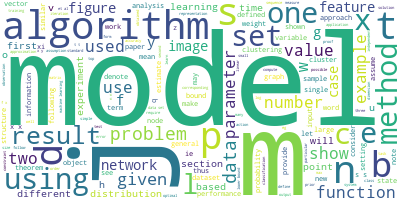

In [12]:
# visualize the word cloud
wc.to_image()